In [32]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import stan
import pandas as pd
from scipy import stats
from datetime import datetime
import nest_asyncio
nest_asyncio.apply()
import time
import math
import scipy.stats
import arviz as az

In [33]:
# They integrate to 1 
b0 = pd.read_csv('data/bottom_interpolated.csv', names=['gn1','density'],header=None )
l0 = pd.read_csv('data/light_interpolated.csv', names=['gn1','density'], header=None )
c0 = pd.read_csv('data/charm_interpolated.csv', names=['gn1','density'], header=None )

# parameters to sonstruct the data
pi = [0.2,0.3,0.5]  # proportion expected for each class
                    # slot0: probability of class0 x class0 x class0 x class0
                    # slot1: probability of class1 x class1 x class1 x class1
                    # slot2: probability of class0 x class0 x class1 x class1 (in any order)
theta_prior = [[2.5,7],[1.5,2], [5,2.5]]
classes = [0,1,2]  # which curves to compare, 0=light, 1=charm, 2 = bottom

In [34]:
b0

,gn1,density
0,-7.000000,0.000000
1,-6.808081,0.000135
2,-6.616162,0.000270
3,-6.424242,0.000405
4,-6.232323,0.000540
...,...,...
95,11.232323,0.032507
96,11.424242,0.024380
97,11.616162,0.016254
98,11.808081,0.008127


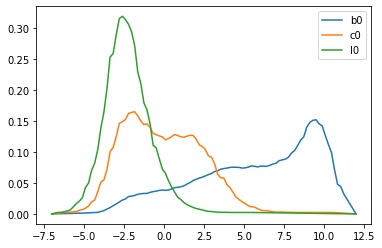

In [35]:
#plt.plot(l0['gn1'],l0['density'],label = 'l0')
plt.plot(b0['gn1'],b0['density'],label = 'b0')
plt.plot(c0['gn1'],c0['density'],label = 'c0')
plt.plot(l0['gn1'],l0['density'],label = 'l0')
plt.legend()
plt.show()

In [36]:
# reshape true curves to m bins
m = 20
vec = np.linspace(0,99,m)
myrows = [int(x) for x in vec]
ltrue = l0.iloc[myrows]
ctrue = c0.iloc[myrows]
btrue = b0.iloc[myrows]
ltrue.reset_index(drop=True, inplace=True)
ctrue.reset_index(drop=True, inplace=True)
btrue.reset_index(drop=True, inplace=True)
curves = [ltrue, ctrue, btrue]    
class0 = curves[classes[0]]
class1 = curves[classes[1]]
class2 = curves[classes[2]]
names = ['$j$','$c$','$b$']
name0 = names[classes[0]]
name1 = names[classes[1]]
name2 = names[classes[2]]
classname = [name0, name1, name2]    

1.0299575398241438


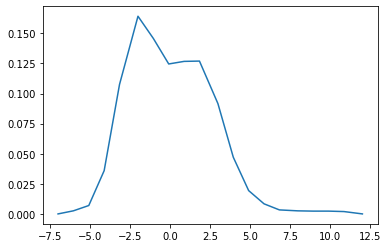

In [37]:
from scipy.integrate import simps
# Calcular el área bajo la curva usando la regla de Simpson
area = simps(ctrue['density'], ctrue['gn1'])
plt.plot(ctrue['gn1'],ctrue['density'])
print(area)
plt.show()

In [38]:
# determine start, stop and step of binning
start = min(class0['gn1'])
stop = max(class0['gn1'])
m = len(ltrue)  # just to be sure we didn't screw it in thinning the lists
step = (stop - start)/(m-1)
midbins = [start+(i+1/2)*step for i in range(0,m-1)]
edgebins = np.linspace(start,stop,m)
# These are the steps and bins for the betas that are in [0,1] and should be translated to the real start/stop span
start1 = 0
stop1 = 1
step1 = (stop1 - start1)/(m-1)
midbins1 = [start1+(i+1/2)*step1 for i in range(0,m-1)]

In [39]:
# Distributions
prior_distribution = [ [midbins, stats.beta.pdf(midbins1,theta_prior[0][0],theta_prior[0][1])], [midbins, stats.beta.pdf(midbins1,theta_prior[1][0],theta_prior[1][1])], [midbins, stats.beta.pdf(midbins1,theta_prior[2][0],theta_prior[2][1])] ]
true_distribution = [ [midbins, [ (class0.iloc[i]['density']+class0.iloc[i+1]['density'])/2 for i in range(m-1)] ] , [midbins, [ (class1.iloc[i]['density']+class1.iloc[i+1]['density'])/2 for i in range(m-1)] ], [midbins, [ (class2.iloc[i]['density']+class2.iloc[i+1]['density'])/2 for i in range(m-1)] ] ]

# Make probabilities sum 1
for i in range(len(true_distribution)):
    tmp = sum(true_distribution[i][1])+0.0*(m-1)
    true_distribution[i][1] = [(x+0.0)/tmp for x in true_distribution[i][1]]

for i in range(len(prior_distribution)):
    tmp = sum(prior_distribution[i][1])+0.0*(m-1)
    print(tmp)
    prior_distribution[i][1] = [(x+0.0)/tmp for x in prior_distribution[i][1]]
                                # We ad 0.001 to avoid a "-inf" in log_prior that doe snot enter into c++ STAN code

#print(prior_distribution[0][1])
      

19.027859712265222
19.059861106940335
19.01266379843048


In [40]:
i

2

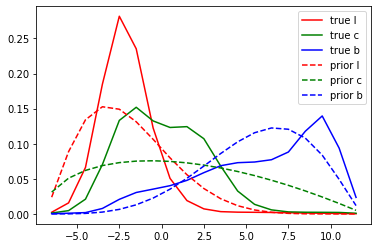

In [41]:
plt.plot(true_distribution[0][0],true_distribution[0][1],label='true l',color='red')
plt.plot(true_distribution[1][0],true_distribution[1][1],label='true c',color='green')
plt.plot(true_distribution[2][0],true_distribution[2][1],label='true b',color='blue')
plt.plot(prior_distribution[0][0],prior_distribution[0][1],ls='--',label='prior l',color='red')
plt.plot(prior_distribution[1][0],prior_distribution[1][1],ls='--',label='prior c',color='green')
plt.plot(prior_distribution[2][0],prior_distribution[2][1],ls='--',label='prior b',color='blue')
plt.legend()
plt.show()

In [42]:
# Updated classes and probabilities
classes = ["jjjj", "bbjj", "ccjj", "ccbb", "cccc", "bbbb"]  # j is l0, b is b0, c is c0
p = [0.8, 0.06, 0.05, 0.04, 0.03, 0.02]  # probabilities for each class
m = 20  # Number of bins

# Simulate data
myseed = 3
N = 1000
np.random.seed(myseed)
features = 4  #dimensions, 4 jets

X = []
sampledclass0, sampledclass1, sampledclass2 = [], [], []


for i in range(N):
    myclass = np.random.choice(len(classes), p=p)
    
    if myclass == 1:  # Clase bbjj con permutaciones
        z = np.random.randint(6)
        b01, b02 = np.random.choice(range(1, m), size=2, p=true_distribution[2][1])
        j01, j02 = np.random.choice(range(1, m), size=2, p=true_distribution[0][1])
        sampled = [
            [b01, b02, j01, j02], [b01, j01, b02, j02], [b01, j01, j02, b02],
            [j01, b01, b02, j02], [j01, b01, j02, b02], [j01, j02, b01, b02]
        ]
        labels = [
            ['b', 'b', 'j', 'j'], ['b', 'j', 'b', 'j'], ['b', 'j', 'j', 'b'],
            ['j', 'b', 'b', 'j'], ['j', 'b', 'j', 'b'], ['j', 'j', 'b', 'b']
        ]
        sampledclass1 += [b01, b02]
        sampledclass0 += [j01, j02]
        X.append([myclass] + sampled[z] + labels[z])

    elif myclass == 2:  # Clase ccjj con permutaciones
        z = np.random.randint(6)
        c01, c02 = np.random.choice(range(1, m), size=2, p=true_distribution[1][1])
        j01, j02 = np.random.choice(range(1, m), size=2, p=true_distribution[0][1])
        sampled = [
            [c01, c02, j01, j02], [c01, j01, c02, j02], [c01, j01, j02, c02],
            [j01, c01, c02, j02], [j01, c01, j02, c02], [j01, j02, c01, c02]
        ]
        labels = [
            ['c', 'c', 'j', 'j'], ['c', 'j', 'c', 'j'], ['c', 'j', 'j', 'c'],
            ['j', 'c', 'c', 'j'], ['j', 'c', 'j', 'c'], ['j', 'j', 'c', 'c']
        ]
        sampledclass2 += [c01, c02]
        sampledclass0 += [j01, j02]
        X.append([myclass] + sampled[z] + labels[z])

    elif myclass == 3:  # Clase ccbb con permutaciones
        z = np.random.randint(6)
        c01, c02 = np.random.choice(range(1, m), size=2, p=true_distribution[1][1])
        b01, b02 = np.random.choice(range(1, m), size=2, p=true_distribution[2][1])
        sampled = [
            [c01, c02, b01, b02], [c01, b01, c02, b02], [c01, b01, b02, c02],
            [b01, c01, c02, b02], [b01, c01, b02, c02], [b01, b02, c01, c02]
        ]
        labels = [
            ['c', 'c', 'b', 'b'], ['c', 'b', 'c', 'b'], ['c', 'b', 'b', 'c'],
            ['b', 'c', 'c', 'b'], ['b', 'c', 'b', 'c'], ['b', 'b', 'c', 'c']
        ]
        sampledclass2 += [c01, c02]
        sampledclass1 += [b01, b02]
        X.append([myclass] + sampled[z] + labels[z])

    elif myclass == 4:  # Clase cccc
        tmp = np.random.choice(range(1, m), size=features, p=true_distribution[1][1])
        sampledclass2 += tmp.tolist()
        X.append([myclass] + tmp.tolist() + ['c', 'c', 'c', 'c'])

    elif myclass == 5:  # Clase bbbb
        tmp = np.random.choice(range(1, m), size=features, p=true_distribution[2][1])
        sampledclass1 += tmp.tolist()
        X.append([myclass] + tmp.tolist() + ['b', 'b', 'b', 'b'])

    elif myclass == 0:  # Clase jjjj
        tmp = np.random.choice(range(1, m), size=features, p=true_distribution[0][1])
        sampledclass0 += tmp.tolist()
        X.append([myclass] + tmp.tolist() + ['j', 'j', 'j', 'j'])
    else:
        print('Algun error tuviste')

# Convertir los datos a DataFrame
X = np.array(X)
X0 = pd.DataFrame(X, columns=['class', 'xn0', 'xn1', 'xn2', 'xn3', 'label_xn0', 'label_xn1', 'label_xn2', 'label_xn3'])
X0[['xn0', 'xn1', 'xn2', 'xn3']] = X0[['xn0', 'xn1', 'xn2', 'xn3']].apply(pd.to_numeric, errors='coerce')

In [43]:
X0

,class,xn0,xn1,xn2,xn3,label_xn0,label_xn1,label_xn2,label_xn3
0,0,6,5,5,7,j,j,j,j
1,2,4,4,6,6,c,j,c,j
2,0,5,4,5,5,j,j,j,j
3,3,8,13,6,11,c,b,c,b
4,0,5,4,5,6,j,j,j,j
...,...,...,...,...,...,...,...,...,...
995,0,5,7,4,6,j,j,j,j
996,0,5,3,9,11,j,j,j,j
997,0,6,4,4,5,j,j,j,j
998,0,7,5,6,4,j,j,j,j


In [64]:
# Obtener el conteo de cada clase
class_counts = X0['class'].value_counts()
print(class_counts)
# Calcular las fracciones dividiendo por el total N
class_fractions = class_counts / N

# Convertir a lista
class_fractions_list = class_fractions.tolist()

class_fractions_list_rounded = [round(fraction, 3) for fraction in class_fractions_list]
print('')
print(classes)
print(p,'true fraction')
print(class_fractions_list_rounded,'data fraction')


class
0    794
2     64
1     47
4     40
3     39
5     16
Name: count, dtype: int64

['jjjj', 'bbjj', 'ccjj', 'ccbb', 'cccc', 'bbbb']
[0.8, 0.06, 0.05, 0.04, 0.03, 0.02] true fraction
[0.794, 0.064, 0.047, 0.04, 0.039, 0.016] data fraction


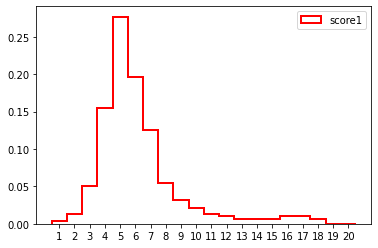

In [45]:
bin_edges = np.arange(0.5, m + 1.5, 1)

plt.hist(X0['xn0'], histtype='step', density=1, color='red', bins=bin_edges,label='score1',lw=2)


plt.legend()
plt.xticks(range(1, m+1))
plt.show()

In [46]:
score = X0[['xn0','xn1', 'xn2', 'xn3']].values.tolist()
score

[[6, 5, 5, 7],
 [4, 4, 6, 6],
 [5, 4, 5, 5],
 [8, 13, 6, 11],
 [5, 4, 5, 6],
 [4, 5, 8, 9],
 [7, 7, 5, 4],
 [6, 5, 4, 5],
 [5, 5, 5, 7],
 [5, 5, 5, 4],
 [5, 4, 5, 5],
 [6, 6, 6, 5],
 [5, 6, 5, 5],
 [4, 9, 4, 6],
 [6, 5, 6, 3],
 [4, 4, 4, 4],
 [4, 8, 6, 5],
 [4, 8, 7, 6],
 [7, 6, 6, 8],
 [5, 6, 4, 4],
 [6, 9, 7, 5],
 [5, 8, 7, 5],
 [4, 4, 3, 7],
 [4, 5, 3, 4],
 [6, 5, 5, 6],
 [7, 4, 4, 4],
 [8, 10, 5, 6],
 [7, 5, 3, 7],
 [6, 4, 6, 7],
 [5, 6, 4, 5],
 [7, 4, 7, 7],
 [6, 5, 6, 10],
 [9, 7, 6, 10],
 [11, 6, 7, 6],
 [4, 5, 6, 6],
 [5, 5, 4, 5],
 [7, 18, 16, 3],
 [6, 5, 5, 4],
 [7, 10, 4, 7],
 [7, 5, 3, 3],
 [3, 4, 5, 5],
 [6, 5, 6, 4],
 [7, 4, 4, 4],
 [1, 3, 5, 4],
 [7, 6, 6, 5],
 [5, 5, 6, 4],
 [7, 4, 5, 8],
 [4, 6, 6, 6],
 [5, 2, 4, 6],
 [5, 11, 9, 5],
 [6, 5, 7, 4],
 [4, 6, 17, 17],
 [17, 8, 5, 7],
 [10, 10, 5, 10],
 [7, 6, 7, 4],
 [8, 6, 4, 4],
 [6, 7, 11, 5],
 [4, 6, 4, 5],
 [3, 6, 5, 6],
 [10, 3, 6, 6],
 [5, 6, 7, 5],
 [6, 4, 5, 4],
 [1, 4, 4, 5],
 [7, 5, 7, 5],
 [6, 6, 5, 8],
 [4, 5,

In [47]:
my_mixture_4d = """
functions {
  real partial_sum(array[,] int score_slice,
                   int start, int end,
                   vector yj,
                   vector yb,
                   vector yc,
                   vector theta)
  {
    real permutation_factor = 1.0/6;
    real partial_target = 0;
    
    vector[6] lp;   // Six distinct classes: jjjj, bbjj (+perm), bbbb, bbcc (+perm), jjcc (+perm), and cccc.
    vector[6] lp2;  // To handle permutations for bbjj
    vector[6] lp3;  // To handle permutations for bbcc
    vector[6] lp4;  // To handle permutations for jjcc.
    
    int slice_length = end - start + 1;

    //jjjj, bbjj, ccjj, ccbb, cccc, bbbb is the order of the classes
    for (k in 1:slice_length) {
      // Permutations for bbjj
      lp2[1] = log(permutation_factor) + log(yj)[score_slice[k,1]] + log(yj)[score_slice[k,2]] + log(yb)[score_slice[k,3]] + log(yb)[score_slice[k,4]];
      lp2[2] = log(permutation_factor) + log(yj)[score_slice[k,1]] + log(yb)[score_slice[k,2]] + log(yj)[score_slice[k,3]] + log(yb)[score_slice[k,4]];
      lp2[3] = log(permutation_factor) + log(yj)[score_slice[k,1]] + log(yb)[score_slice[k,2]] + log(yb)[score_slice[k,3]] + log(yj)[score_slice[k,4]];
      lp2[4] = log(permutation_factor) + log(yb)[score_slice[k,1]] + log(yj)[score_slice[k,2]] + log(yj)[score_slice[k,3]] + log(yb)[score_slice[k,4]];
      lp2[5] = log(permutation_factor) + log(yb)[score_slice[k,1]] + log(yj)[score_slice[k,2]] + log(yb)[score_slice[k,3]] + log(yj)[score_slice[k,4]];
      lp2[6] = log(permutation_factor) + log(yb)[score_slice[k,1]] + log(yb)[score_slice[k,2]] + log(yj)[score_slice[k,3]] + log(yj)[score_slice[k,4]];

      // Assign probabilities for the six classes
      lp[1] = log(yj)[score_slice[k,1]] + log(yj)[score_slice[k,2]] + log(yj)[score_slice[k,3]] + log(yj)[score_slice[k,4]]; // jjjj
      lp[2] = log_sum_exp(lp2);    // bbjj + permutations
      lp[6] = log(yb)[score_slice[k,1]] + log(yb)[score_slice[k,2]] + log(yb)[score_slice[k,3]] + log(yb)[score_slice[k,4]]; // bbbb

      // Permutations for bbcc
      lp3[1] = log(permutation_factor) + log(yb)[score_slice[k,1]] + log(yb)[score_slice[k,2]] + log(yc)[score_slice[k,3]] + log(yc)[score_slice[k,4]];
      lp3[2] = log(permutation_factor) + log(yb)[score_slice[k,1]] + log(yc)[score_slice[k,2]] + log(yb)[score_slice[k,3]] + log(yc)[score_slice[k,4]];
      lp3[3] = log(permutation_factor) + log(yb)[score_slice[k,1]] + log(yc)[score_slice[k,2]] + log(yc)[score_slice[k,3]] + log(yb)[score_slice[k,4]];
      lp3[4] = log(permutation_factor) + log(yc)[score_slice[k,1]] + log(yb)[score_slice[k,2]] + log(yb)[score_slice[k,3]] + log(yc)[score_slice[k,4]];
      lp3[5] = log(permutation_factor) + log(yc)[score_slice[k,1]] + log(yb)[score_slice[k,2]] + log(yc)[score_slice[k,3]] + log(yb)[score_slice[k,4]];
      lp3[6] = log(permutation_factor) + log(yc)[score_slice[k,1]] + log(yc)[score_slice[k,2]] + log(yb)[score_slice[k,3]] + log(yb)[score_slice[k,4]];
      lp[4] = log_sum_exp(lp3);    // bbcc + permutations

      // Permutations for jjcc
      lp4[1] = log(permutation_factor) + log(yj)[score_slice[k,1]] + log(yj)[score_slice[k,2]] + log(yc)[score_slice[k,3]] + log(yc)[score_slice[k,4]];
      lp4[2] = log(permutation_factor) + log(yj)[score_slice[k,1]] + log(yc)[score_slice[k,2]] + log(yj)[score_slice[k,3]] + log(yc)[score_slice[k,4]];
      lp4[3] = log(permutation_factor) + log(yj)[score_slice[k,1]] + log(yc)[score_slice[k,2]] + log(yc)[score_slice[k,3]] + log(yj)[score_slice[k,4]];
      lp4[4] = log(permutation_factor) + log(yc)[score_slice[k,1]] + log(yj)[score_slice[k,2]] + log(yj)[score_slice[k,3]] + log(yc)[score_slice[k,4]];
      lp4[5] = log(permutation_factor) + log(yc)[score_slice[k,1]] + log(yj)[score_slice[k,2]] + log(yc)[score_slice[k,3]] + log(yj)[score_slice[k,4]];
      lp4[6] = log(permutation_factor) + log(yc)[score_slice[k,1]] + log(yc)[score_slice[k,2]] + log(yj)[score_slice[k,3]] + log(yj)[score_slice[k,4]];
      lp[3] = log_sum_exp(lp4);    // jjcc + permutations

      lp[5] = log(yc)[score_slice[k,1]] + log(yc)[score_slice[k,2]] + log(yc)[score_slice[k,3]] + log(yc)[score_slice[k,4]]; // cccc

      partial_target += log_mix(theta, lp);
    }

    return partial_target;
  }
}

data {
  int<lower=1> m;  // steps in the discretization
  int<lower=1> N;  // data points
  array[N,4] int<lower=1, upper=m> score;  // b-tagging score for jet#1
}

parameters {
  simplex[6] theta;  // Mixture coefficients of 6 classes as a simplex
  
  simplex[m] w_j_mode;  // Dirichlet weights for the background (jjjj and permutations)
  vector<lower=0>[m-1] a_j;  // Normal parameters for background
  
  simplex[m] w_b_mode;  // Dirichlet weights for the signal (bbbb and permutations)
  vector<lower=0>[m-1] a_b;  // Normal parameters for signal
  
  simplex[m] w_c_mode;  // Dirichlet weights for component c (cccc and permutations)
  vector<lower=0>[m-1] a_c;  // Normal parameters for component c
}

transformed parameters {
  ordered[2] y_label_switch_1;
  ordered[2] y_label_switch_2;
  ordered[2] y_label_switch_3;
  ordered[2] y_label_switch_4;
  ordered[2] y_label_switch_5;
  ordered[2] y_label_switch_6;
  ordered[2] y_label_switch_7;

  vector[m] p_j;  // Approximate distribution for j
  vector[m-1] sign_j;  // Signs for combination
  vector[m] logp_j;  // Log-probabilities
  
  sign_j = rep_vector(-1.0, m-1);
  p_j = rep_vector(0.0, m);

  for (k in 1:m) {
    if (k > 1) {
      for (j in 1:(k-1)) {
        sign_j[j] = 1.0;
      }
    }
    logp_j[1] = 0.0;
    for (j in 2:m) {
      logp_j[j] = logp_j[j-1] + sign_j[j-1] * a_j[j-1];
    }
    p_j += softmax(logp_j) * w_j_mode[k];
  }

  vector[m] p_b;  // Approximate distribution for b
  vector[m-1] sign_b;  // Signs for combination
  vector[m] logp_b;  // Log-probabilities

  sign_b = rep_vector(-1.0, m-1);
  p_b = rep_vector(0.0, m);

  for (k in 1:m) {
    if (k > 1) {
      for (j in 1:(k-1)) {
        sign_b[j] = 1.0;
      }
    }
    logp_b[1] = 0.0;
    for (j in 2:m) {
      logp_b[j] = logp_b[j-1] + sign_b[j-1] * a_b[j-1];
    }
    p_b += softmax(logp_b) * w_b_mode[k];
  }
  
  vector[m] p_c;  // Approximate distribution for c
  vector[m-1] sign_c;  // Signs for combination
  vector[m] logp_c;  // Log-probabilities
  
  sign_c = rep_vector(-1.0, m-1);
  p_c = rep_vector(0.0, m);

  for (k in 1:m) {
    if (k > 1) {
      for (j in 1:(k-1)) {
        sign_c[j] = 1.0;
      }
    }
    logp_c[1] = 0.0;
    for (j in 2:m) {
      logp_c[j] = logp_c[j-1] + sign_c[j-1] * a_c[j-1];
    }
    p_c += softmax(logp_c) * w_c_mode[k];
  }

  

  y_label_switch_1[1] = p_c[5];
  y_label_switch_1[2] = p_j[5];
  
  y_label_switch_2[1] = p_c[4];
  y_label_switch_2[2] = p_j[4];
  
  y_label_switch_3[1] = p_b[5];
  y_label_switch_3[2] = p_j[5];

  y_label_switch_4[1] = p_b[8];
  y_label_switch_4[2] = p_c[8];

  y_label_switch_5[1] = p_j[8];
  y_label_switch_5[2] = p_c[8];
  
  y_label_switch_6[1] = p_c[17];
  y_label_switch_6[2] = p_b[17];

  y_label_switch_7[1] = p_j[17];
  y_label_switch_7[2] = p_b[17];
  



}

model {
  int grainsize = 1;  // Adjust for parallel performance

  // Priors
  theta ~ dirichlet(rep_vector(1.0, 6));

  a_j ~ normal(0, 0.5);
  a_b ~ normal(0, 0.5);
  a_c ~ normal(0, 0.5);

  w_j_mode ~ dirichlet(rep_vector(1.0, m));
  w_b_mode ~ dirichlet(rep_vector(1.0, m));
  w_c_mode ~ dirichlet(rep_vector(1.0, m));

  target += reduce_sum(partial_sum, score, grainsize, p_j, p_b, p_c, theta);
}

"""

In [51]:
# Start the timer
start_time_4d = time.time()

# Build and sample from the 2D mixture model
model_4d = stan.build(my_mixture_4d, data={'m': m, 'N': len(score), 'score':score},random_seed=33)
fit_4d = model_4d.sample(num_chains=4, num_samples=1000, num_warmup = 2000,delta = 0.95)
df_4d = fit_4d.to_frame()

# Stop the timer
end_time_4d = time.time()

# Calculate the elapsed time
elapsed_time_4d = end_time_4d - start_time_4d

# Print the elapsed time
print(f"Time taken to run the 2D model: {elapsed_time_4d:.2f} seconds")


Building: found in cache, done.
Messages from stanc:
Warning in '/tmp/httpstan_epprh1vk/model_u5al4u5r.stan', line 192, column 12: The
    variable partial_sum may not have been assigned a value before its use.
Sampling:   0%
Sampling:   0% (1/12000)
Sampling:   0% (2/12000)
Sampling:   0% (3/12000)
Sampling:   0% (4/12000)
Sampling:   1% (103/12000)
Sampling:   2% (203/12000)
Sampling:   3% (302/12000)
Sampling:   3% (401/12000)
Sampling:   4% (501/12000)
Sampling:   5% (601/12000)
Sampling:   6% (701/12000)
Sampling:   7% (801/12000)
Sampling:   8% (901/12000)
Sampling:   8% (1001/12000)
Sampling:   9% (1101/12000)
Sampling:  10% (1201/12000)
Sampling:  11% (1300/12000)
Sampling:  12% (1400/12000)
Sampling:  12% (1500/12000)
Sampling:  13% (1600/12000)
Sampling:  14% (1700/12000)
Sampling:  15% (1800/12000)
Sampling:  16% (1900/12000)
Sampling:  17% (2000/12000)
Sampling:  18% (2100/12000)
Sampling:  18% (2200/12000)
Sampling:  19% (2300/12000)
Sampling:  20% (2400/12000)
Sampling:  

warn:Rejecting initial value:
warn:  Error evaluating the log probability at the initial value.
warn:Exception: model_u5al4u5r_namespace::log_prob: y_label_switch_1 is not a valid ordered vector. The element at 2 is 0.0187664, but should be greater than the previous element, 0.0936449 (in '/tmp/httpstan_qkriop77/model_u5al4u5r.stan', line 82, column 2 to column 30)
warn:Rejecting initial value:
warn:  Error evaluating the log probability at the initial value.
warn:Exception: model_u5al4u5r_namespace::log_prob: y_label_switch_1 is not a valid ordered vector. The element at 2 is 0.0482178, but should be greater than the previous element, 0.0959995 (in '/tmp/httpstan_qkriop77/model_u5al4u5r.stan', line 82, column 2 to column 30)
warn:Rejecting initial value:
warn:  Error evaluating the log probability at the initial value.
warn:Exception: model_u5al4u5r_namespace::log_prob: y_label_switch_4 is not a valid ordered vector. The element at 2 is 0.0661514, but should be greater than the previo

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_u5al4u5r_namespace::log_prob: y_label_switch_6 is not a valid ordered vector. The element at 2 is 0.0214764, but should be greater than the previous element, 0.0217286 (in '/tmp/httpstan_qkriop77/model_u5al4u5r.stan', line 87, column 2 to column 30)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: mode

  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_u5al4u5r_namespace::log_prob: y_label_switch_6 is not a valid ordered vector. The element at 2 is 0.0210951, but should be greater than the previous element, 0.0211013 (in '/tmp/httpstan_qkriop77/model_u5al4u5r.stan', line 87, column 2 to column 30)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_u5al4u5r_namespace::log_prob: y_label_switch_6 is not a valid ordered vector. The element at 2 is 0.0214893, but should be greater than

  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_u5al4u5r_namespace::log_prob: y_label_switch_6 is not a valid ordered vector. The element at 2 is 0.0197282, but should be greater than the previous element, 0.0197494 (in '/tmp/httpstan_qkriop77/model_u5al4u5r.stan', line 87, column 2 to column 30)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_u5al4u5r_namespace::log_prob: y_label_switch_6 is not a valid ordered vector. The element at 2 is 0.0213788, but should be greater than the previous element, 0.0214376 (in '/tmp/httpstan_qkriop77/model_u5al4u5r.stan', line 87, column 2 to col

...

  Exception: model_u5al4u5r_namespace::log_prob: y_label_switch_4 is not a valid ordered vector. The element at 2 is 0.132792, but should be greater than the previous element, 0.13281 (in '/tmp/httpstan_qkriop77/model_u5al4u5r.stan', line 85, column 2 to column 30)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_u5al4u5r_namespace::log_prob: y_label_switch_4 is not a valid ordered vector. The element at 2 is 0.132103, but should be greater than the previous element, 0.132115 (in '/tmp/httpstan_qkriop77/model_u5al4u5r.stan', line 85, column 2 to column 30)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices,

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_u5al4u5r_namespace::log_prob: y_label_switch_4 is not a valid ordered vector. The element at 2 is 0.131184, but should be greater than the previous element, 0.131189 (in '/tmp/httpstan_qkriop77/model_u5al4u5r.stan', line 85, column 2 to column 30)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_

  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_u5al4u5r_namespace::log_prob: y_label_switch_4 is not a valid ordered vector. The element at 2 is 0.13167, but should be greater than the previous element, 0.131671 (in '/tmp/httpstan_qkriop77/model_u5al4u5r.stan', line 85, column 2 to column 30)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_u5al4u5r_namespace::log_prob: y_label_switch_4 is not a valid ordered vector. The element at 2 is 0.132033, but should be greater than the

  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_u5al4u5r_namespace::log_prob: y_label_switch_4 is not a valid ordered vector. The element at 2 is 0.135509, but should be greater than the previous element, 0.135512 (in '/tmp/httpstan_qkriop77/model_u5al4u5r.stan', line 85, column 2 to column 30)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_u5al4u5r_namespace::log_prob: y_label_switch_4 is not a valid ordered vector. The element at 2 is 0.135763, but should be greater than th

  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_u5al4u5r_namespace::log_prob: y_label_switch_2 is not a valid ordered vector. The element at 2 is 0.233228, but should be greater than the previous element, 0.233237 (in '/tmp/httpstan_qkriop77/model_u5al4u5r.stan', line 83, column 2 to column 30)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_u5al4u5r_namespace::log_prob: y_label_switch_2 is not a valid ordered vector. The element at 2 is 0.233351, but should be greater than the previous element, 0.233361 (in '/tmp/httpstan_qkriop77/model_u5al4u5r.stan', line 83, column 2 to column 

In [52]:
df_ordenado = df_4d.sort_values(by='lp__', ascending=False)  #ordeno por probabilidad
df_ordenado[:5]

parameters,lp__,accept_stat__,stepsize__,treedepth__,n_leapfrog__,divergent__,energy__,theta.1,theta.2,theta.3,...,logp_c.11,logp_c.12,logp_c.13,logp_c.14,logp_c.15,logp_c.16,logp_c.17,logp_c.18,logp_c.19,logp_c.20
draws,,,,,,,,,,,,,,,,,,,,,
2225,-8731.647606,0.950359,0.045242,4.0,30.0,1.0,8791.019961,0.875870,0.059319,0.007103,...,4.902145,5.332274,6.500668,6.926216,7.100183,7.764729,7.809296,7.955218,8.657183,8.857111
1958,-8732.677968,0.990727,0.017033,6.0,116.0,1.0,8788.172113,0.881951,0.057220,0.017556,...,4.767443,5.353300,6.013127,6.646242,7.394285,7.917084,8.288758,8.742697,9.287941,9.911728
1580,-8733.262310,0.953533,0.052431,6.0,63.0,0.0,8787.244593,0.874971,0.069970,0.003310,...,3.926191,4.256918,5.129693,5.901389,6.088142,6.514036,7.053031,7.105330,7.361575,7.764779
2245,-8733.549364,0.968632,0.045242,5.0,61.0,1.0,8796.922810,0.868680,0.078737,0.002253,...,4.228803,4.514200,4.810583,5.003647,5.095193,5.314043,5.498185,5.647081,5.870884,6.008609
2221,-8733.686002,0.966911,0.045242,5.0,37.0,1.0,8792.524447,0.867529,0.088578,0.002858,...,4.952306,5.535660,6.371366,6.707339,7.348625,8.124493,8.212614,8.336796,9.118775,9.392945


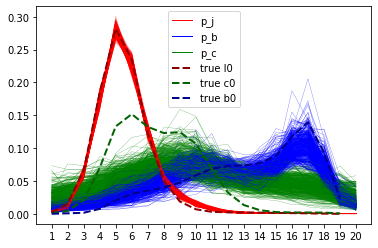

In [53]:
plt.figure()
m=20
#Normalizing and plotting inferred distributions
for i in range(500):
    # Extract the p_j and p_b values for the current sample
    p_j_values = np.array([df_ordenado.iloc[i]['p_j.' + str(x)] for x in range(1, 21)])
    p_b_values = np.array([df_ordenado.iloc[i]['p_b.' + str(x)] for x in range(1, 21)])
    p_c_values = np.array([df_ordenado.iloc[i]['p_c.' + str(x)] for x in range(1, 21)])
    
    # Plot the normalized curves
    if i == 0:
        plt.plot(range(1, 21), p_j_values, lw = 1,color='red', label='p_j')
        plt.plot(range(1, 21), p_b_values, lw = 1,color='blue', label='p_b')
        plt.plot(range(1, 21), p_c_values, lw = 1,color='green', label='p_c')

    else:
        plt.plot(range(1, 21), p_j_values, lw = 0.2,color='red')
        plt.plot(range(1, 21), p_b_values, lw = 0.2,color='blue')
        plt.plot(range(1, 21), p_c_values, lw = 0.2,color='green')


plt.plot(range(1,m),np.array(true_distribution[0][1]),ls='--',lw=2,color='darkred',label='true l0')
plt.plot(range(1,m),np.array(true_distribution[1][1]),ls='--',lw=2,color='darkgreen',label='true c0')
plt.plot(range(1,m),np.array(true_distribution[2][1]),ls='--',lw=2,color='darkblue',label='true b0')

        
plt.xticks(np.arange(1,m+1))
#plt.xlim(1,m)
#plt.ylim(0,0.05) #hacemos zoom
plt.legend()
#plt.grid(alpha=0.5)
plt.show()


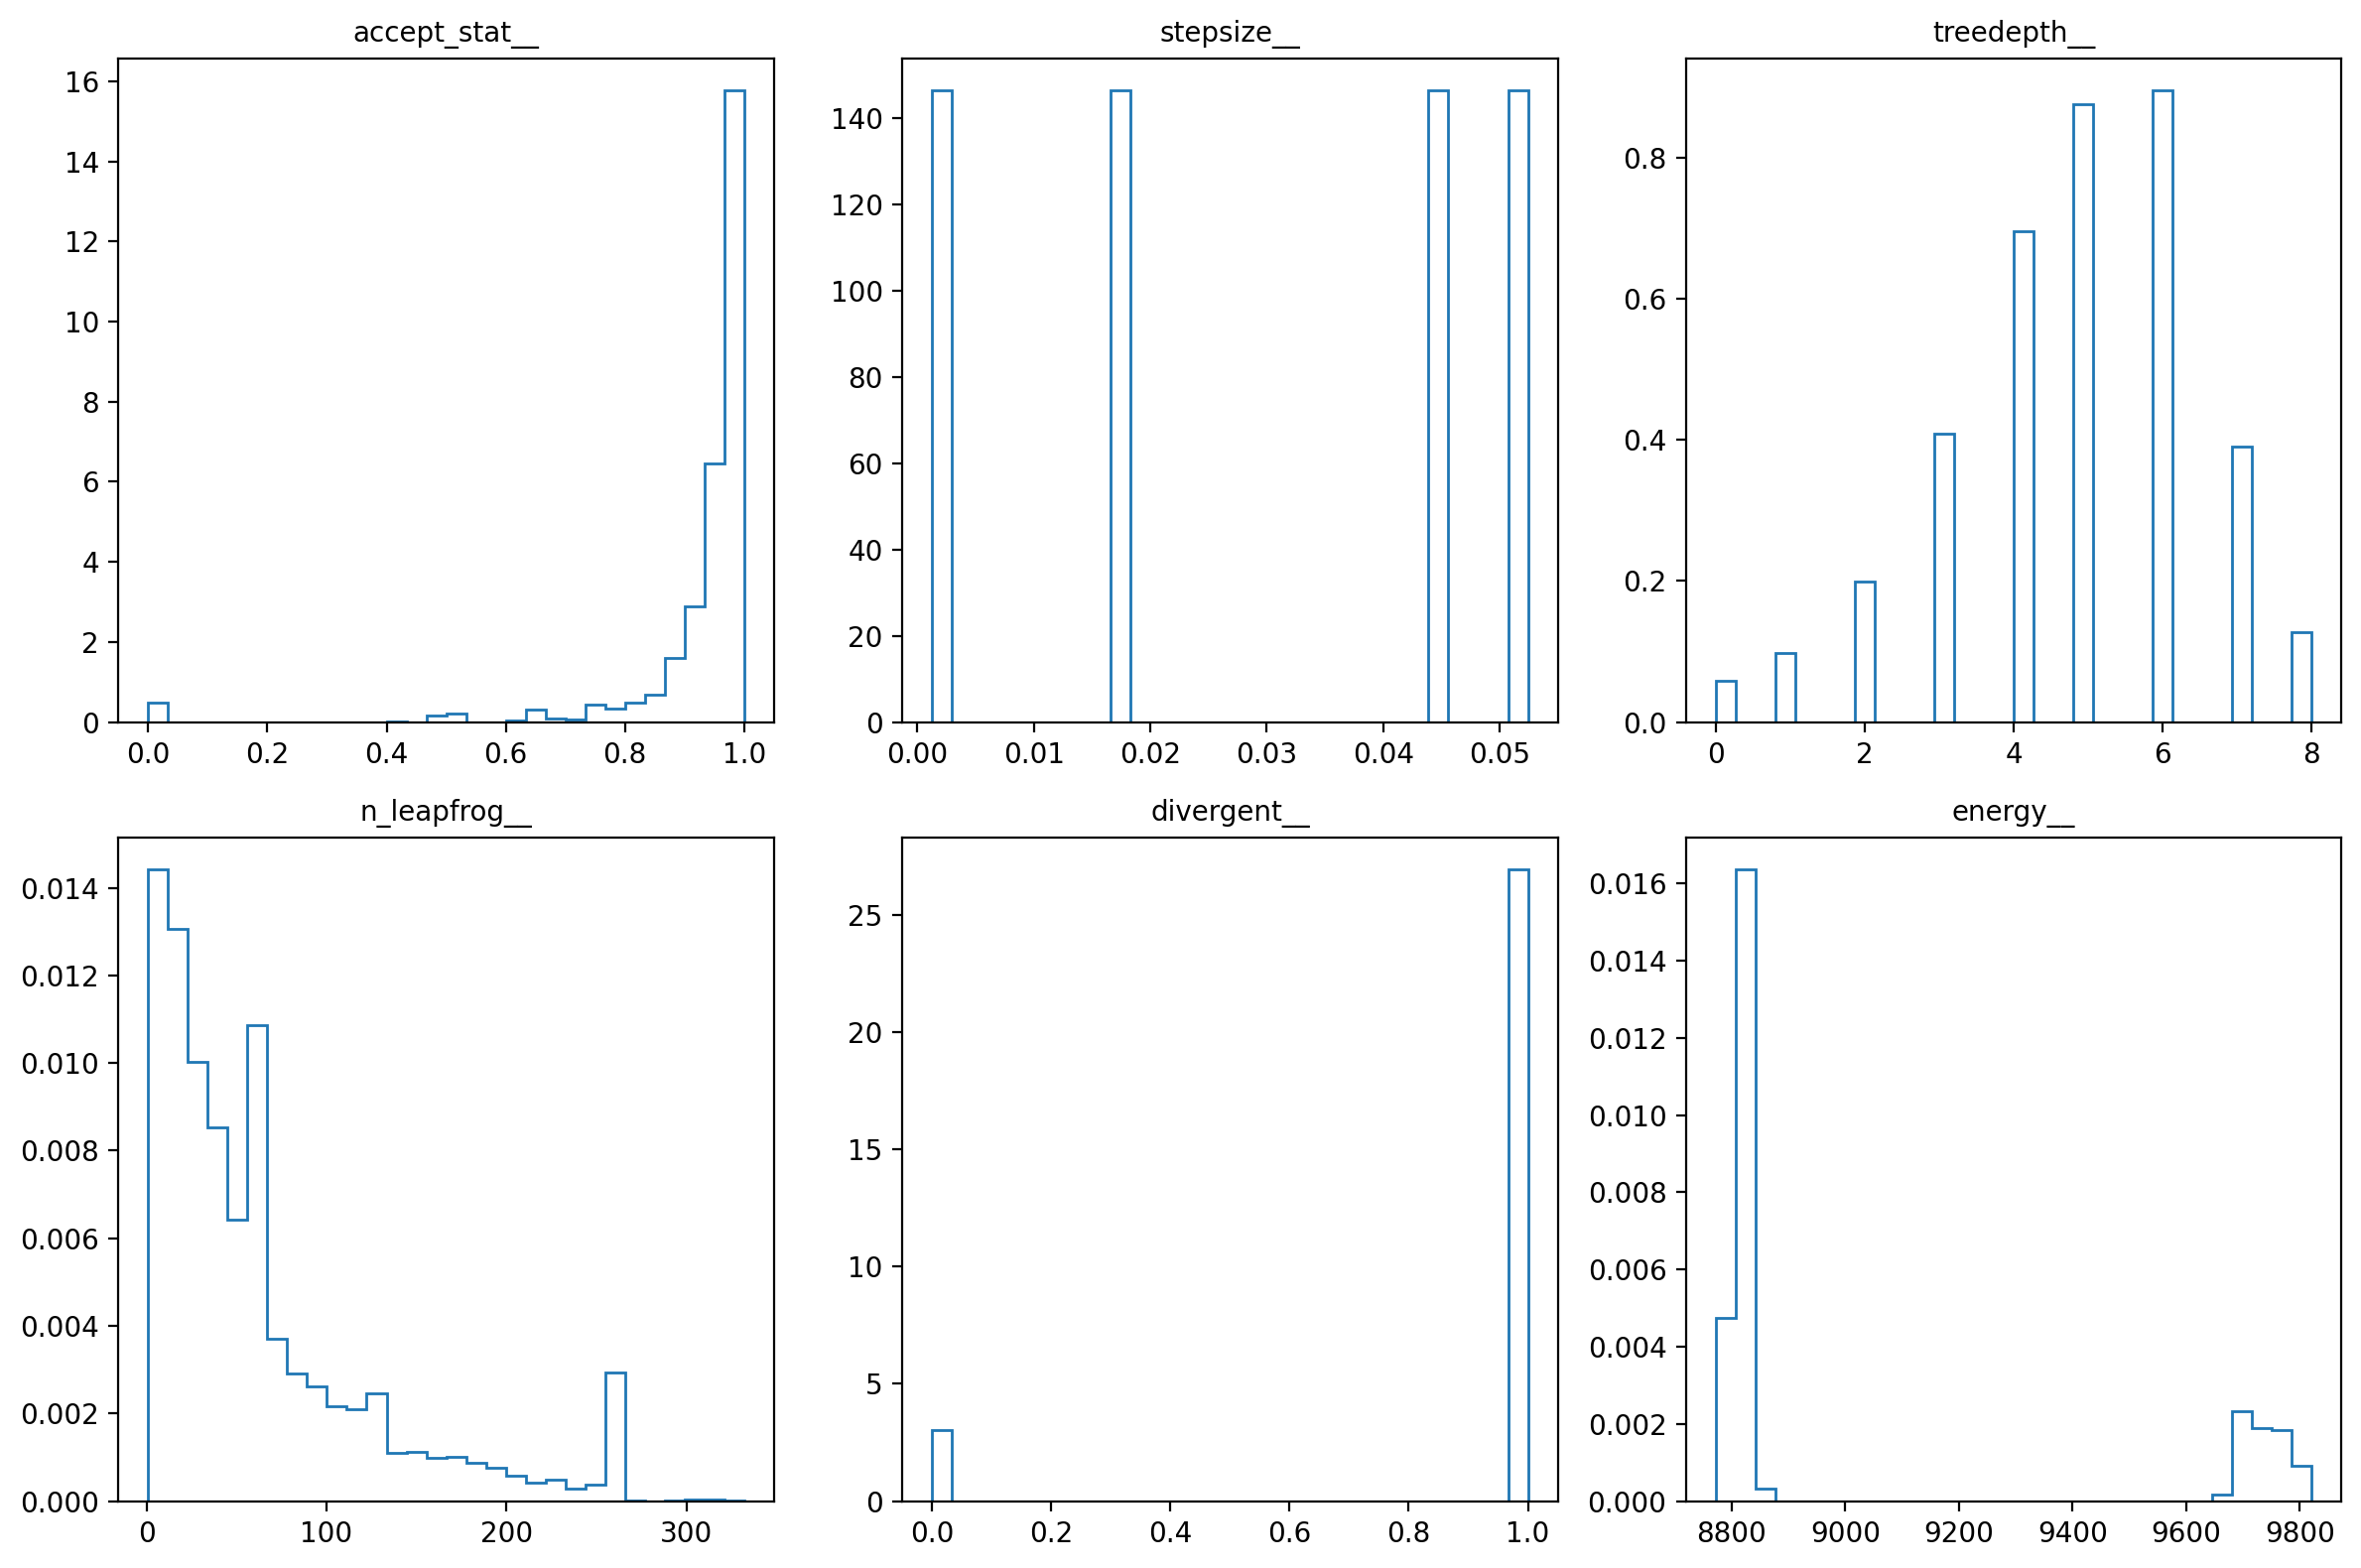

In [54]:
# Now define the posterior_4d with the relevant diagnostics columns
posterior_4d = df_4d[['accept_stat__', 'stepsize__', 'treedepth__', 'n_leapfrog__', 'divergent__', 'energy__']]

# Create subplots for each of the 6 diagnostic parameters
fig, axes = plt.subplots(2, 3, figsize=(12, 8), dpi=200)

# List of the diagnostic parameters
parameters = ['accept_stat__', 'stepsize__', 'treedepth__', 'n_leapfrog__', 'divergent__', 'energy__']

# Loop over the parameters and create histograms in subplots
for i, param in enumerate(parameters):
    row = i // 3  # Define the row for the subplot
    col = i % 3   # Define the column for the subplot
    axes[row, col].hist(posterior_4d[param], bins=30, histtype='step', density=True)
    axes[row, col].set_title(param, fontsize=10)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()


In [55]:
posterior = az.from_pystan(fit_4d)

# Get the ArviZ summary
summary_df = az.summary(posterior)

summary_df.sort_values(by = 'r_hat',ascending = False).head(20)

/home/tomas/.local/lib/python3.10/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/tomas/.local/lib/python3.10/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/tomas/.local/lib/python3.10/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
logp_j[6],7.275,1.880,5.550,10.632,0.914,0.705,7.0,12.0,1.63
logp_j[8],9.708,2.771,7.392,14.674,1.361,1.047,7.0,12.0,1.63
p_c[9],0.062,0.027,0.022,0.102,0.011,0.008,7.0,11.0,1.63
a_j[4],1.177,1.325,0.199,3.570,0.654,0.504,7.0,16.0,1.63
logp_c[19],12.463,7.446,6.197,25.648,3.659,2.828,7.0,12.0,1.62
a_j[3],0.545,0.269,0.159,0.939,0.112,0.084,7.0,12.0,1.62
y_label_switch_2[0],0.092,0.085,0.022,0.243,0.042,0.032,7.0,11.0,1.62
logp_j[5],6.063,1.194,4.820,8.195,0.565,0.437,7.0,13.0,1.62
logp_j[7],8.637,2.429,6.573,13.010,1.191,0.917,7.0,12.0,1.62
logp_j[9],10.470,2.744,8.099,15.373,1.343,1.034,7.0,12.0,1.62


In [56]:
r_hat_values = summary_df['r_hat'].values

print(r_hat_values)

mean_r_hat = np.nanmean(r_hat_values)  # Promedio excluyendo NaN
std_r_hat = np.nanstd(r_hat_values)    # Desviación estándar excluyendo NaN
print('')
print(f"Promedio: {mean_r_hat:.4f} ± {std_r_hat:.4f}")

[1.56 1.6  1.4  1.6  1.59 1.6  1.54 1.56 1.6  1.54 1.23 1.43 1.26 1.21
 1.15 1.55 1.6  1.08 1.56 1.55 1.29 1.55 1.2  1.55 1.56 1.54 1.09 1.6
 1.57 1.62 1.63 1.58 1.61 1.54 1.54 1.54 1.18 1.3  1.15 1.61 1.61 1.08
 1.58 1.62 1.52 1.56 1.59 1.21 1.53 1.51 1.53 1.57 1.4  1.22 1.3  1.44
 1.14 1.42 1.34 1.19 1.36 1.3  1.19 1.24 1.29 1.62 1.6  1.54 1.37 1.14
 1.1  1.52 1.28 1.14 1.21 1.52 1.09 1.55 1.3  1.19 1.58 1.56 1.47 1.6
 1.1  1.22 1.13 1.61 1.1  1.46 1.26 1.27 1.27 1.45 1.3  1.49 1.46 1.48
 1.47 1.55 1.57 1.59 1.47 1.52 1.51 1.57 1.55 1.12 1.1  1.16 1.55 1.42
 1.31 1.28 1.28 1.14 1.59 1.52 1.36 1.54 1.14 1.6  1.6  1.61 1.04 1.62
 1.54 1.54 1.04 1.56 1.54 1.56 1.54 1.6  1.56 1.54 1.56 1.54 1.54 1.54
 1.54 1.04 1.58 1.54 1.56 1.55 1.38 1.55 1.55 1.55 1.56 1.53 1.55 1.54
 1.54 1.54 1.55  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan
  nan  nan  nan  nan  nan  nan  nan  nan  nan 1.09 1.59 1.35 1.18 1.62
 1.63 1.62 1.63 1.62 1.61 1.62 1.61 1.61 1.61 1.62 1.61 1.61 1.61 1.61
 1.59 1.

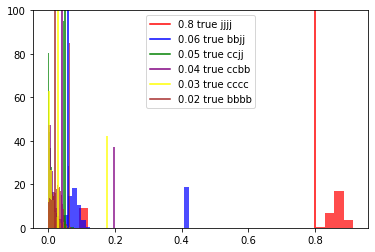

In [57]:
plt.figure()

plt.hist(df_4d['theta.1'],bins=30,alpha=0.7,density=True,color='red')
plt.axvline(p[0],color='red',label=f'{p[0]} true {classes[0]}')

plt.hist(df_4d['theta.2'],bins=30,alpha=0.7,density=True,color='blue')
plt.axvline(p[1],color='blue',label=f'{p[1]} true {classes[1]}')

plt.hist(df_4d['theta.3'],bins=30,alpha=0.7,density=True,color = 'green')
plt.axvline(p[2],color='green',label=f'{p[2]} true {classes[2]}')

plt.hist(df_4d['theta.4'],bins=30,alpha=0.7,density=True,color = 'purple')
plt.axvline(p[3],color='purple',label=f'{p[3]} true {classes[3]}')

plt.hist(df_4d['theta.5'],bins=30,alpha=0.7,density=True,color = 'yellow')
plt.axvline(p[4],color='yellow',label=f'{p[4]} true {classes[4]}')

plt.hist(df_4d['theta.6'],bins=30,alpha=0.7,density=True,color = 'brown')
plt.axvline(p[5],color='brown',label=f'{p[5]} true {classes[5]}')

#plt.xlim(0,0.1)
plt.legend()
plt.show()

In [58]:
mydata = df_4d[['theta.1', 'theta.2', 'theta.3', 'theta.4', 'theta.5', 'theta.6']]   
mydata = np.round(mydata / 0.05) * 0.05
tmp = []
# Grid
values = np.linspace(0, 1, 21)
# Allow a small tolerance for rounding errors
tolerance = 1e-6

# Make the possible combinations of 6 numbers that sum approximately to 1
for i in values:
    for j in values:
        for k in values:
            for l in values:
                for m in values:
                    for n in values:
                        if abs(i + j + k + l + m + n - 1.0) < tolerance:
                            tmp.append([i, j, k, l, m, n])

total = len(mydata)
delta = 1/total
print(total, delta)
ternary_data = pd.DataFrame(tmp, columns=classes)
ternary_data['v'] = [0] * len(ternary_data)
ternary_data

4000 0.00025


,jjjj,bbjj,ccjj,ccbb,cccc,bbbb,v
0,0.00,0.00,0.00,0.00,0.00,1.00,0
1,0.00,0.00,0.00,0.00,0.05,0.95,0
2,0.00,0.00,0.00,0.00,0.10,0.90,0
3,0.00,0.00,0.00,0.00,0.15,0.85,0
4,0.00,0.00,0.00,0.00,0.20,0.80,0
...,...,...,...,...,...,...,...
53125,0.95,0.00,0.00,0.00,0.05,0.00,0
53126,0.95,0.00,0.00,0.05,0.00,0.00,0
53127,0.95,0.00,0.05,0.00,0.00,0.00,0
53128,0.95,0.05,0.00,0.00,0.00,0.00,0


In [59]:
force_uniform = 5  #solo es distinto de 1 o no

if force_uniform != 1:
    for k in range(total):
        # Filtrar en ternary_data las filas que coincidan con los valores de mydata en todas las columnas
        mask = (
            (ternary_data[classes[0]] == mydata.iloc[k, 0]) &
            (ternary_data[classes[1]] == mydata.iloc[k, 1]) &
            (ternary_data[classes[2]] == mydata.iloc[k, 2]) &
            (ternary_data[classes[3]] == mydata.iloc[k, 3]) &
            (ternary_data[classes[4]] == mydata.iloc[k, 4]) &
            (ternary_data[classes[5]] == mydata.iloc[k, 5])
        )
        # Incrementar la probabilidad 'v' en las filas correspondientes
        ternary_data.loc[mask, 'v'] += delta
else:
    # Si se fuerza la distribución uniforme, se asigna una probabilidad uniforme a todos los puntos
    ternary_data['v'] = [1 / len(ternary_data)] * len(ternary_data)

    
ternary_data

/tmp/ipykernel_98716/4268035911.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.00025]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ternary_data.loc[mask, 'v'] += delta


,jjjj,bbjj,ccjj,ccbb,cccc,bbbb,v
0,0.00,0.00,0.00,0.00,0.00,1.00,0.0
1,0.00,0.00,0.00,0.00,0.05,0.95,0.0
2,0.00,0.00,0.00,0.00,0.10,0.90,0.0
3,0.00,0.00,0.00,0.00,0.15,0.85,0.0
4,0.00,0.00,0.00,0.00,0.20,0.80,0.0
...,...,...,...,...,...,...,...
53125,0.95,0.00,0.00,0.00,0.05,0.00,0.0
53126,0.95,0.00,0.00,0.05,0.00,0.00,0.0
53127,0.95,0.00,0.05,0.00,0.00,0.00,0.0
53128,0.95,0.05,0.00,0.00,0.00,0.00,0.0


In [60]:
p_rounded = np.round(np.array(p) / 0.05) * 0.05
p_rounded

array([0.8 , 0.05, 0.05, 0.05, 0.05, 0.  ])

In [61]:
# Filtros por cada clase y valor correspondiente
mask = (
    (ternary_data[classes[0]] == p_rounded[0]) &
    (ternary_data[classes[1]] == p_rounded[1]) &
    (ternary_data[classes[2]] == p_rounded[2]) &
    (ternary_data[classes[3]] == p_rounded[3]) &
    (ternary_data[classes[4]] == p_rounded[4]) &
    (ternary_data[classes[5]] == p_rounded[5])
)

# Extraer el valor 'v' y redondearlo

prob_true = np.round(ternary_data[mask]['v'].values[0],3)
prob_true, delta, prob_true/delta

(0.0, 0.00025, 0.0)

In [62]:
mean1 = np.average(ternary_data[classes[0]], weights=ternary_data['v'])
mean2 = np.average(ternary_data[classes[1]], weights=ternary_data['v'])
mean3 = np.average(ternary_data[classes[2]], weights=ternary_data['v'])
mean4 = np.average(ternary_data[classes[3]], weights=ternary_data['v'])
mean5 = np.average(ternary_data[classes[4]], weights=ternary_data['v'])
mean6 = np.average(ternary_data[classes[5]], weights=ternary_data['v'])

fraction_mean = np.array([mean1, mean2, mean3, mean4, mean5, mean6])

distance = np.round(np.linalg.norm(fraction_mean - np.array(p)),3)

print('classes:', classes,'\nfraction mean:', np.round(fraction_mean,3),'\nReal fracion:', p, '\nAbsolute distance:',distance,'\ndelta:',delta,'-->','prob_true:',prob_true,', increase factor:',prob_true/delta)

classes: ['jjjj', 'bbjj', 'ccjj', 'ccbb', 'cccc', 'bbbb'] 
fraction mean: [0.586 0.197 0.022 0.078 0.077 0.04 ] 
Real fracion: [0.8, 0.06, 0.05, 0.04, 0.03, 0.02] 
Absolute distance: 0.263 
delta: 0.00025 --> prob_true: 0.0 , increase factor: 0.0


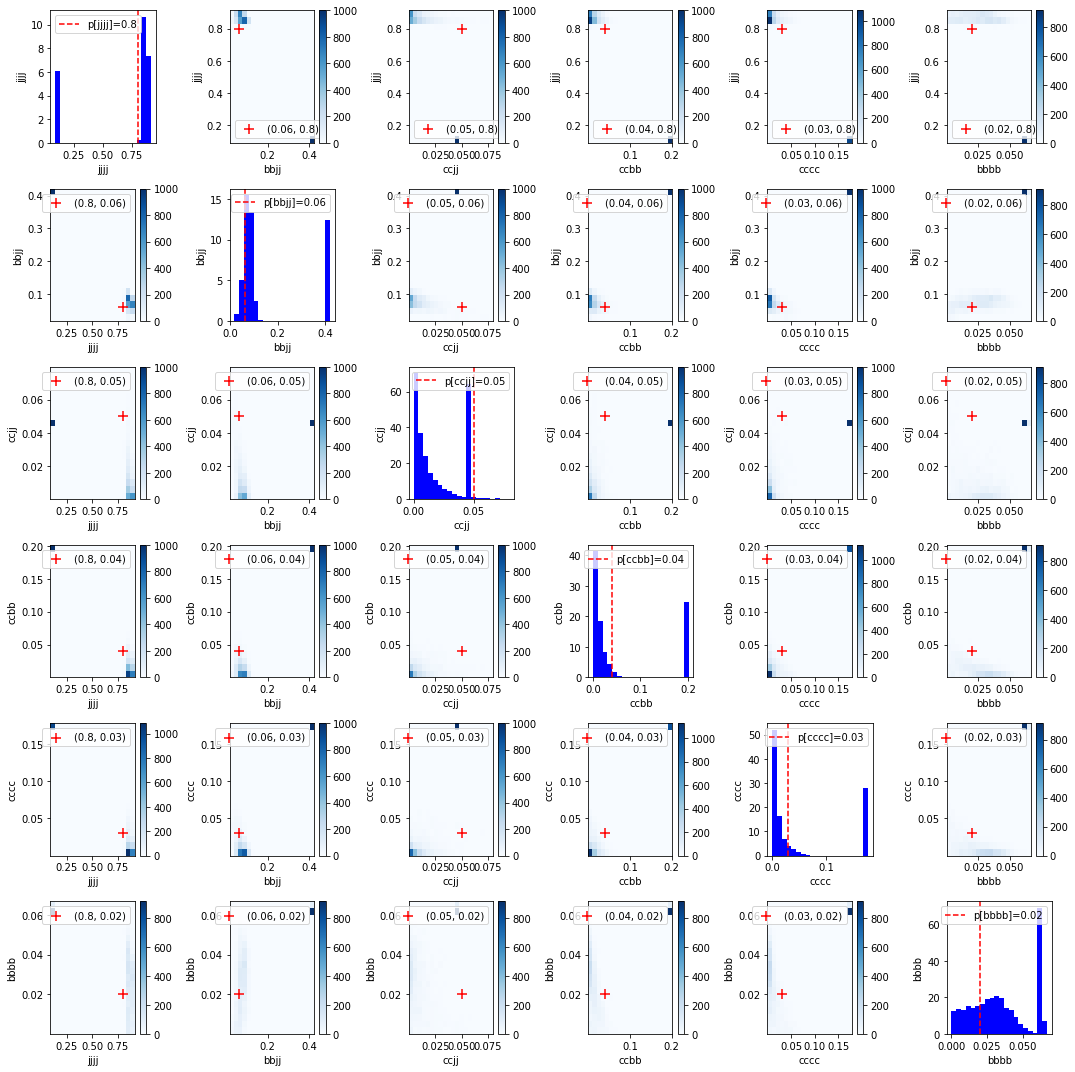

In [63]:
# Assuming df_4d contains your theta.1 to theta.6 columns
mydata = df_4d[['theta.1', 'theta.2', 'theta.3', 'theta.4', 'theta.5', 'theta.6']]

# Initialize the subplot grid
fig, axes = plt.subplots(6, 6, figsize=(15, 15))

# Loop through each subplot and create scatter plots or histograms
for i in range(6):
    for j in range(6):
        if i == j:
            # Plot a histogram on the diagonal
            axes[i, j].hist(mydata.iloc[:, i], bins=20, color='blue',density=True)
            axes[i, j].axvline(p[i], color='red', linestyle='--', label=f'p[{classes[i]}]={p[i]}')
            axes[i, j].set_ylabel(f'{classes[i]}')
            axes[i, j].set_xlabel(f'{classes[i]}')
            axes[i, j].legend()
        else:
            # 2D Histogram for off-diagonal combinations
            h = axes[i, j].hist2d(mydata.iloc[:, j], mydata.iloc[:, i], bins=20, cmap='Blues')
            # Add a red cross at the real value position (p[j], p[i])
            axes[i, j].scatter(p[j], p[i], color='red', marker='+', s=100, label=f'({p[j]}, {p[i]})')
            axes[i, j].set_xlabel(f'{classes[j]}')
            axes[i, j].set_ylabel(f'{classes[i]}')
            axes[i, j].legend(loc='best')
            # Add a color bar for the density
            fig.colorbar(h[3], ax=axes[i, j])

# Adjust layout
plt.tight_layout()
plt.show()